Propagazione GEO in corso per 30 giorni...

  MISSION ANALYSIS: VARIAZIONE PARAMETRI DOPO 30 GIORNI (GEO)
  Modello: Gravità 10x10, SRP, Luni-Solar Third Body (NO DRAG)
1. SEMIASSE MAGGIORE (a)
   Iniziale: 42164.140 km
   Finale:   42160.948 km
   Delta:    -3192.25 metri (-3.192248 km) (Oscillazione indotta dalle tesserali, East-West drift)
--------------------------------------------------------------------
2. ECCENTRICITÀ (e)
   Iniziale: 0.000100
   Finale:   0.000069
   Delta:    -0.000031 (Deriva causata dalla Pressione di Radiazione Solare)
--------------------------------------------------------------------
3. INCLINAZIONE (i)
   Iniziale: 0.01000 deg
   Finale:   0.06885 deg
   Delta:    0.05885 deg (North-South drift causato da Luni-Solare)
--------------------------------------------------------------------
4. RAAN (Ω)
   Iniziale: 0.000 deg
   Finale:   89.834 deg (Standard Modulo 360)
   Delta:    89.834 deg
----------------------------------------------------------------

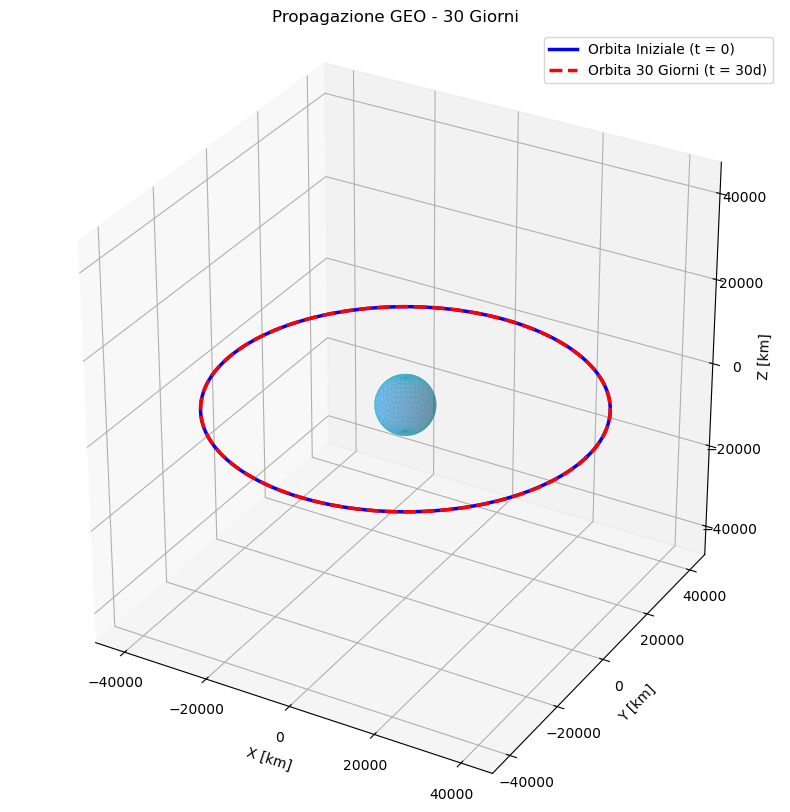

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. DEFINIZIONE DEL TEMPO E DEI FRAME
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. CREAZIONE DELL'ORBITA (GEO)
# ==========================================
# A 42164 km il periodo è di un giorno siderale (~23h 56m)
a = 42164140.0  
e = 0.0001      # Quasi circolare (evita singolarità matematiche)
i = math.radians(0.01) # Quasi equatoriale (evita singolarità)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 2500.0) # Massa tipica di un satellite TLC

# ==========================================
# 4. CONFIGURAZIONE DEL PROPAGATORE
# ==========================================
min_step = 0.001
max_step = 1000.0 # Step massimi più grandi perché la dinamica GEO è lenta
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. AGGIUNTA DELLE PERTURBAZIONI (NO DRAG)
# ==========================================
# Gravità EGM96 (Armoniche 10x10) - in GEO contano soprattutto J2 e le tesserali (J22)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# Third Body (Sole e Luna - Dominanti in GEO per l'inclinazione)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# Pressione di Radiazione Solare (SRP - Dominante in GEO per l'eccentricità)
propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(35.0, 1.2))) # Area esposta molto grande (pannelli solari)

# ==========================================
# 6. PROPAGAZIONE (30 GIORNI)
# ==========================================
giorni = 30.0
duration = giorni * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagazione GEO in corso per {int(giorni)} giorni...")
final_state = propagator.propagate(final_date)

ephemeris = ephemeris_generator.getGeneratedEphemeris()
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

# Calcolo del Delta normalizzato (percorso angolare più breve rispetto allo zero iniziale)
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: VARIAZIONE PARAMETRI DOPO {int(giorni)} GIORNI (GEO)")
print("  Modello: Gravità 10x10, SRP, Luni-Solar Third Body (NO DRAG)")
print("====================================================================")
print(f"1. SEMIASSE MAGGIORE (a)")
print(f"   Iniziale: {a/1000:.3f} km")
print(f"   Finale:   {a_fin/1000:.3f} km")
print(f"   Delta:    {(a_fin - a):.2f} metri ({(a_fin - a)/1000:.6f} km) (Oscillazione indotta dalle tesserali, East-West drift)")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITÀ (e)")
print(f"   Iniziale: {e:.6f}")
print(f"   Finale:   {e_fin:.6f}")
print(f"   Delta:    {e_fin - e:.6f} (Deriva causata dalla Pressione di Radiazione Solare)")
print("--------------------------------------------------------------------")
print(f"3. INCLINAZIONE (i)")
print(f"   Iniziale: {math.degrees(i):.5f} deg")
print(f"   Finale:   {i_fin:.5f} deg")
print(f"   Delta:    {i_fin - math.degrees(i):.5f} deg (North-South drift causato da Luni-Solare)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (Ω)")
print(f"   Iniziale: {math.degrees(raan):.3f} deg")
print(f"   Finale:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:    {delta_raan:.3f} deg")
print("--------------------------------------------------------------------")
print(f"5. ARGOMENTO DEL PERIGEO (ω)")
print(f"   Iniziale: {math.degrees(omega):.3f} deg")
print(f"   Finale:   {omega_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:    {delta_omega:.3f} deg")
print("====================================================================\n")

# ==========================================
# 8. VISUALIZZAZIONE 3D
# ==========================================
print("Generazione grafico 3D in corso...")
periodo_orbitale = 86164.0  # Un giorno siderale in secondi

def estrai_orbita(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = estrai_orbita(0, periodo_orbitale)                                  
x30, y30, z30 = estrai_orbita(duration - periodo_orbitale, duration)             

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Orbita Iniziale (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, linestyle='dashed', label='Orbita 30 Giorni (t = 30d)')

# Limiti del grafico impostati per contenere la GEO (42000 km)
lim = a / 1000.0 + 5000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Propagazione GEO - 30 Giorni')
ax.legend(loc='upper right')

plt.show()